# AutoGluon.TimeSeries V1.4 Cheatsheet

This notebook contains the key code snippets from the AutoGluon Time Series cheatsheet.

In [14]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

In [15]:
from process_data import *

data_dir = os.path.join(os.getcwd(), 'data')

generacion = pd.read_csv(os.path.join(data_dir,'generacion.csv'))
generacion['timestamp'] = pd.to_datetime(generacion['timestamp'])

In [16]:
generacion.columns

Index(['Codigo Central', 'timestamp', 'Generacion_MWh'], dtype='object')

In [17]:
grouped_generacion=generacion.groupby("Codigo Central")

In [24]:
grouped_generacion.count()

,timestamp,Generacion_MWh
Codigo Central,,
Canela,8377,8377
Canela 2,8377,8377
El Arrayán,4992,4992
EÓLICA VALLE DE LOS VIENTOS_Eólico,7272,7272
Eólica Los Cururos,4488,4488
Eólica Negrete,3576,3576
Eólica Taltal,1728,1728
Eólica Totoral,8377,8377
HUAYCA1,7295,7295


In [25]:
min_date=generacion['timestamp'].min()
max_date=generacion['timestamp'].max()

In [26]:
min_date,max_date

(Timestamp('2014-01-01 00:00:00'), Timestamp('2014-12-31 23:00:00'))

In [27]:
full_date_range = pd.date_range(start=min_date, end=max_date, freq='h')

In [28]:
len(full_date_range)

8760

In [29]:
reindexed_dfs = []
for station,df in grouped_generacion:
    df.set_index('timestamp',inplace=True)
    df=df[~df.index.duplicated(keep='first')]
    df_reindexed = df.reindex(full_date_range)
    df_reindexed['Codigo Central']=df_reindexed['Codigo Central'].bfill()
    df_reindexed['Codigo Central']=df_reindexed['Codigo Central'].ffill()
    df_reindexed['Generacion_MWh']=df_reindexed['Generacion_MWh'].bfill()    
    df_reindexed['Generacion_MWh']=df_reindexed['Generacion_MWh'].interpolate()    
    reindexed_dfs.append(df_reindexed)
    
    #df_reindexed = df.reindex(full_date_range)

In [30]:
generacion_reindexed=pd.concat(reindexed_dfs)

In [32]:
generacion_reindexed.groupby('Codigo Central').count()

,Generacion_MWh
Codigo Central,
Canela,8760
Canela 2,8760
El Arrayán,8760
EÓLICA VALLE DE LOS VIENTOS_Eólico,8760
Eólica Los Cururos,8760
Eólica Negrete,8760
Eólica Taltal,8760
Eólica Totoral,8760
HUAYCA1,8760


In [36]:
generacion_reindexed.reset_index(names='timestamp',inplace=True)

### Convert Raw Data into a TimeSeriesDataFrame

Convert your raw data into the format required by AutoGluon: `TimeSeriesDataFrame`.

In [37]:
# from autogluon.timeseries import TimeSeriesDataFrame # Already imported above
data = TimeSeriesDataFrame(
    generacion_reindexed,
    id_column="Codigo Central",
    timestamp_column="timestamp",
    #static_features=generacion_static,  # Optional metadata/covariates
)

print("Processed Training Data:")
print(data.head(5))

Processed Training Data:
                             Generacion_MWh
item_id timestamp                          
Canela  2014-01-01 00:00:00             4.3
        2014-01-01 01:00:00             2.3
        2014-01-01 02:00:00             2.4
        2014-01-01 03:00:00             1.6
        2014-01-01 04:00:00             1.5


In [39]:
data.infer_frequency()

'h'

In [40]:
train_data,test_data=data.train_test_split(prediction_length=24*7)

In [41]:
test_data.shape,train_data.shape

((315360, 1), (309312, 1))

/var/folders/wd/0sm_658d23ldnfyfjn6y4s6m0000gn/T/ipykernel_8446/3609721456.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


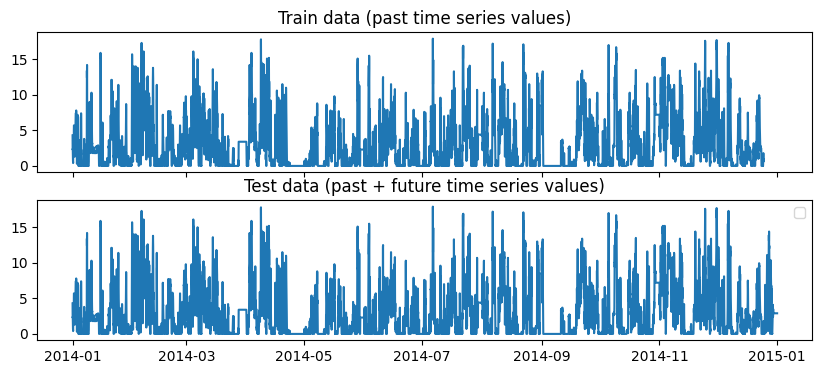

In [42]:
import matplotlib.pyplot as plt 
import numpy as np

item_id = "Canela"
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=[10, 4], sharex=True)
train_ts = train_data.loc[item_id]
test_ts = test_data.loc[item_id]
ax1.set_title("Train data (past time series values)")
ax1.plot(train_ts)
ax2.set_title("Test data (past + future time series values)")
ax2.plot(test_ts)
#for ax in (ax1, ax2):
#    ax.fill_between(np.array([train_ts.index[-1], test_ts.index[-1]]), test_ts.min(), test_ts.max(), color="C1", alpha=0.3, label="Forecast horizon")
plt.legend()
plt.show()

## Training

Train models to forecast the values in the column `target` $30$ steps into the future.

In [43]:
from autogluon.common import space

predictor = TimeSeriesPredictor(
    target="Generacion_MWh",
    prediction_length=24*7, # The number of time steps into the future to forecast
    freq="h",
    # Optional: Additional covariates that are known in the future
    # known_covariates_names=['weekday', 'month'],
).fit(
    train_data,
    hyperparameters={
        "DeepAR": {
            "context_length":space.Int(24, 2*24*7),
            "hidden_size": space.Int(20, 100),
            "dropout_rate": space.Categorical(0.1, 0.3),
        },
    },
    hyperparameter_tune_kwargs="auto",
    enable_ensemble=False,
    time_limit=60 * 5,
)

	Trained 1 models while tuning DeepAR.
	-0.6286       = Validation score (-WQL)
	305.82  s     = Total tuning time
Training complete. Models trained: ['DeepAR/681a67b6']
Total runtime: 307.77 s
Best model: DeepAR/681a67b6
Best model score: -0.6286


## Predicting

Forecast `prediction_length` steps into the future starting from the end of each time series in `train_data`.

In [44]:
predictions = predictor.predict(
    train_data,
    # If you used known_covariates_names during training, pass them here:
    # known_covariates=known_covariates,
)

print("Forecasted Predictions Head:")
print(predictions.head())



Model not specified in predict, will default to the model with the best validation score: DeepAR/681a67b6


Forecasted Predictions Head:
                                 mean       0.1       0.2       0.3       0.4  \
item_id timestamp                                                               
Canela  2014-12-25 00:00:00 -0.316286 -0.421877 -0.186098 -0.041638  0.054443   
        2014-12-25 01:00:00  0.060765 -0.233932 -0.123050 -0.036777  0.005725   
        2014-12-25 02:00:00  0.006069 -0.148601 -0.084507 -0.043424 -0.013113   
        2014-12-25 03:00:00  0.029364 -0.081282 -0.040485 -0.017656 -0.000734   
        2014-12-25 04:00:00  0.008959 -0.098423 -0.041251 -0.024902 -0.009673   

                                  0.5       0.6       0.7       0.8       0.9  
item_id timestamp                                                              
Canela  2014-12-25 00:00:00  0.152273  0.242209  0.348936  0.493154  0.709486  
        2014-12-25 01:00:00  0.059540  0.100006  0.166068  0.239383  0.403597  
        2014-12-25 02:00:00  0.005789  0.038550  0.064581  0.095501  0.135452  
   

In [45]:
predictions['mean'].droplevel('item_id').head()

timestamp
2014-12-25 00:00:00   -0.316286
2014-12-25 01:00:00    0.060765
2014-12-25 02:00:00    0.006069
2014-12-25 03:00:00    0.029364
2014-12-25 04:00:00    0.008959
Name: mean, dtype: float64

## Model Understanding

Understand the contribution of each model.

In [46]:
leaderboard = predictor.leaderboard()
print(leaderboard)

             model  score_val  pred_time_val  fit_time_marginal  fit_order
0  DeepAR/681a67b6  -0.628554        3.27625         269.438325          1


In [47]:
predictor.feature_importance(test_data)

Computing feature importance
Subsample_size 50 is larger than the number of items in the data and will be ignored


,importance,stdev,n,p99_low,p99_high


In [48]:
predictor.leaderboard(test_data)


Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,DeepAR/681a67b6,-0.743857,-0.628554,2.673296,3.27625,269.438325,1


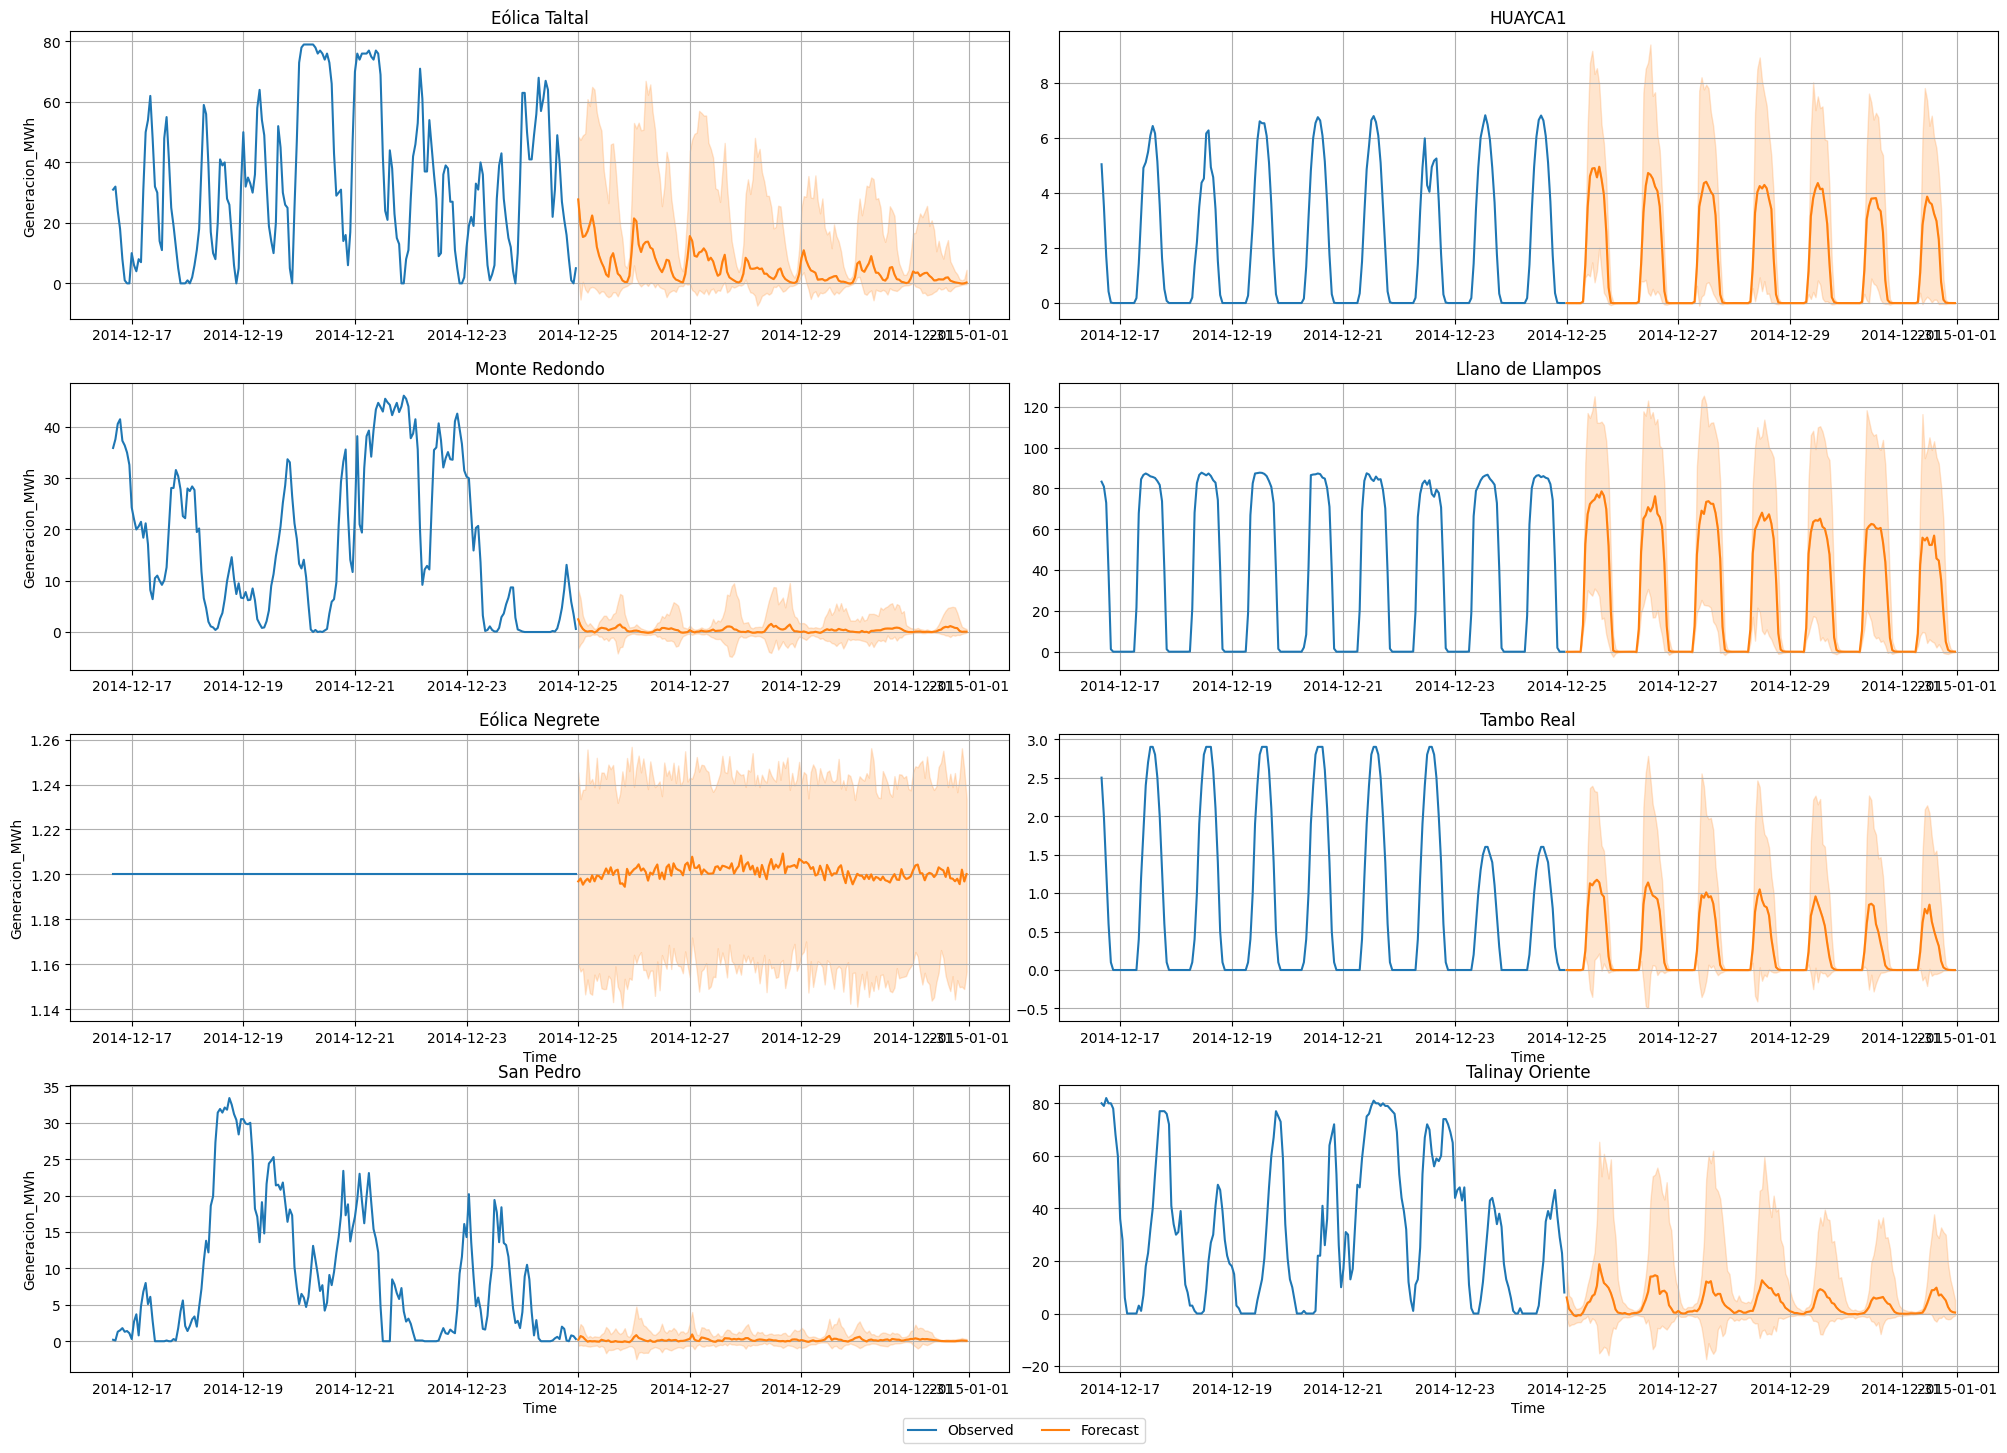

In [50]:
#estaciones_eolica=train_data.static_features[train_data.static_features['Tecnologia']=='EOLICA'].index.to_list()
plt.close('all')
predictor.plot(
    data=train_data,
    predictions=predictions,
    #item_ids=estaciones_eolica,
    max_history_length=200,
);
plt.show()

In [51]:
test_predictions=predictor.predict(test_data)

Model not specified in predict, will default to the model with the best validation score: DeepAR/681a67b6


In [52]:
predictor.evaluate(test_data)

Model not specified in predict, will default to the model with the best validation score: DeepAR/681a67b6


{'WQL': np.float64(-0.7438567273986286)}

In [54]:
import sklearn.metrics
from autogluon.timeseries.metrics import TimeSeriesScorer

class R2Metric(TimeSeriesScorer):
   greater_is_better_internal = True
   optimum = 0.0

   def compute_metric(self, data_future, predictions, target, **kwargs):
      return sklearn.metrics.r2_score(y_true=data_future[target], y_pred=predictions["mean"])

In [58]:
predictor.evaluate(test_data,metrics=['WQL','MAPE','RMSE'])

Model not specified in predict, will default to the model with the best validation score: DeepAR/681a67b6


{'WQL': np.float64(-0.7438567273986286),
 'MAPE': -0.857916646607597,
 'RMSE': np.float64(-17.529947230600566)}

In [66]:
test_data['Generacion_MWh']

item_id    timestamp          
Canela     2014-01-01 00:00:00    4.30
           2014-01-01 01:00:00    2.30
           2014-01-01 02:00:00    2.40
           2014-01-01 03:00:00    1.60
           2014-01-01 04:00:00    1.50
                                  ... 
Ucuquer 2  2014-12-31 19:00:00    0.94
           2014-12-31 20:00:00    0.94
           2014-12-31 21:00:00    0.94
           2014-12-31 22:00:00    0.94
           2014-12-31 23:00:00    0.94
Name: Generacion_MWh, Length: 315360, dtype: float64

In [65]:
test_predictions['mean']

item_id    timestamp          
Canela     2015-01-01 00:00:00    2.365895
           2015-01-01 01:00:00    2.327734
           2015-01-01 02:00:00    1.964451
           2015-01-01 03:00:00    1.465457
           2015-01-01 04:00:00    0.922647
                                    ...   
Ucuquer 2  2015-01-07 19:00:00    0.169991
           2015-01-07 20:00:00    0.218694
           2015-01-07 21:00:00    0.185521
           2015-01-07 22:00:00    0.163546
           2015-01-07 23:00:00    0.139531
Name: mean, Length: 6048, dtype: float64

In [67]:
r2 = R2Metric(prediction_length=predictor.prediction_length)
r2score = r2(
  data=test_data,
  predictions=predictions,
  target=predictor.target,
)
print(f"{r2.name_with_sign} = {r2score}")

R2Metric = 0.11033428765435582
